In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

events = pd.read_csv('RetailRocket/events_filtered.csv')
events.head()

,timestamp,visitorid,event,itemid,transactionid,datetime,date
0,1433224214164,992329,view,248676,NaN,2015-06-02 05:50:14.164,2015-06-02
1,1433223291897,794181,view,439202,NaN,2015-06-02 05:34:51.897,2015-06-02
2,1433220899221,824915,view,428805,NaN,2015-06-02 04:54:59.221,2015-06-02
3,1433222531378,57036,view,334662,NaN,2015-06-02 05:22:11.378,2015-06-02
4,1433223203944,125625,view,17655,NaN,2015-06-02 05:33:23.944,2015-06-02


In [3]:
events['event'].value_counts()

event
view           769877
addtocart       45632
transaction     17954
Name: count, dtype: int64

In [4]:
#simple popularity recommender

item_popularity = (
    events.groupby('itemid')
    .size()
    .reset_index(name='interaction_count')
    .sort_values(by='interaction_count', ascending=False)
)

item_popularity.head(10)

,itemid,interaction_count
38569,461686,1747
21564,257040,982
797,9877,970
10032,119736,800
25999,309778,791
20268,241555,782
26809,320130,744
27225,325310,688
26440,315543,643
26206,312728,640


In [5]:
#weighted popularity recommender

event_weights = {
    'view': 1,
    'addtocart': 3,
    'transaction': 5
}

events['event_weight'] = events['event'].map(event_weights)

weighted_popularity = (
    events.groupby('itemid')['event_weight']
    .sum()
    .reset_index(name='weighted_score')
    .sort_values(by='weighted_score', ascending=False)
)

weighted_popularity.head(10)

,itemid,weighted_score
38569,461686,2693
10032,119736,1268
797,9877,1194
21564,257040,1166
26809,320130,966
26206,312728,962
20268,241555,902
25999,309778,891
37251,445351,868
35246,420960,837


In [17]:
#small scale for repo

weighted_popularity_small = weighted_popularity.head(1000)

weighted_popularity_small.to_csv("E-Commerce Recommendation System/RetailRocket/weighted_popularity.csv", index=False)

In [6]:
#comparing 2 rankings

top_simple = item_popularity.head(10).copy()
top_weighted = weighted_popularity.head(10).copy()

print("Top 10 items by simple popularity:")
print(top_simple)

print("\nTop 10 items by weighted popularity:")
print(top_weighted)

Top 10 items by simple popularity:
       itemid  interaction_count
38569  461686               1747
21564  257040                982
797      9877                970
10032  119736                800
25999  309778                791
20268  241555                782
26809  320130                744
27225  325310                688
26440  315543                643
26206  312728                640

Top 10 items by weighted popularity:
       itemid  weighted_score
38569  461686            2693
10032  119736            1268
797      9877            1194
21564  257040            1166
26809  320130             966
26206  312728             962
20268  241555             902
25999  309778             891
37251  445351             868
35246  420960             837


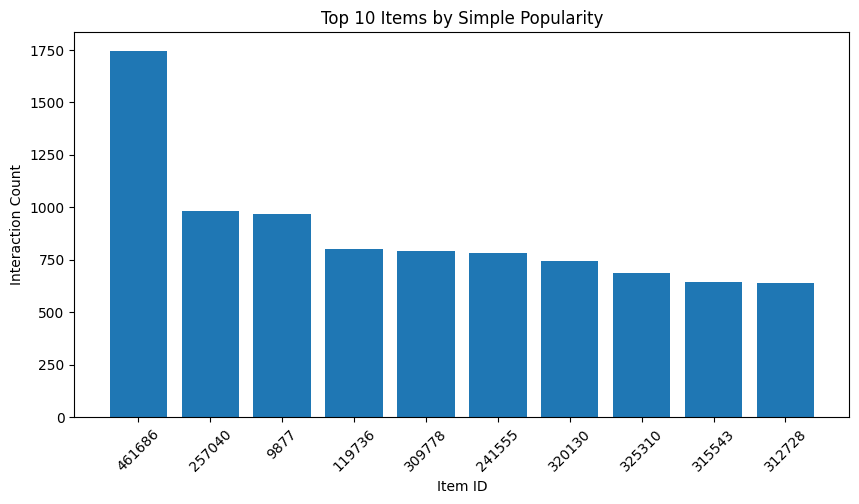

In [7]:
#plot top recommended items (simple)

top_10_simple = item_popularity.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_10_simple['itemid'].astype(str), top_10_simple['interaction_count'])
plt.title('Top 10 Items by Simple Popularity')
plt.xlabel('Item ID')
plt.ylabel('Interaction Count')
plt.xticks(rotation=45)
plt.show()

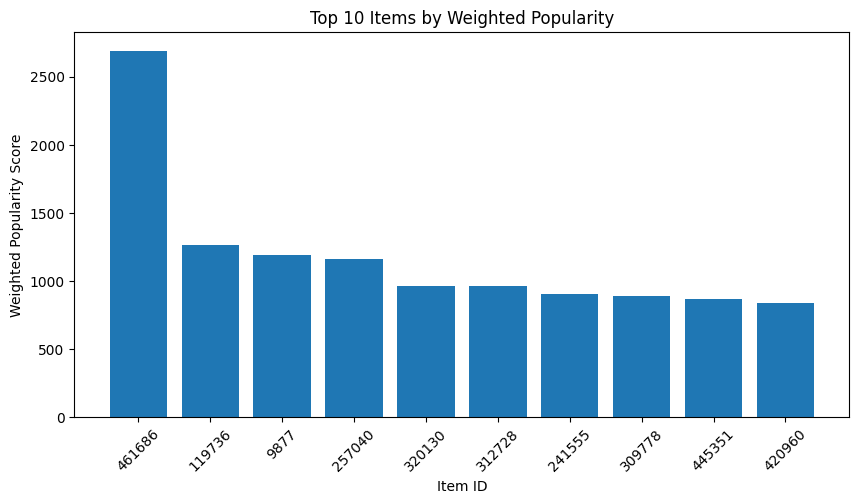

In [8]:
#plot top recommended items (weighted)

top_10_weighted = weighted_popularity.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_10_weighted['itemid'].astype(str), top_10_weighted['weighted_score'])
plt.title('Top 10 Items by Weighted Popularity')
plt.xlabel('Item ID')
plt.ylabel('Weighted Popularity Score')
plt.xticks(rotation=45)
plt.show()


In [9]:
#recomendation function (simple)
def recommend_top_popular_items(popularity_df, n=5):
    return popularity_df.head(n)

In [10]:
#test

recommend_top_popular_items(item_popularity, n=5)

,itemid,interaction_count
38569,461686,1747
21564,257040,982
797,9877,970
10032,119736,800
25999,309778,791


In [11]:
#recommendation function (weighted)

def recommend_top_weighted_items(weighted_df, n=5):
    return weighted_df.head(n)

In [12]:
#test

recommend_top_weighted_items(weighted_popularity, n=5)


,itemid,weighted_score
38569,461686,2693
10032,119736,1268
797,9877,1194
21564,257040,1166
26809,320130,966


In [14]:
#save outputs

item_popularity.to_csv('RetailRocket/item_popularity.csv', index=False)
weighted_popularity.to_csv('RetailRocket/weighted_popularity.csv', index=False)